In [1]:
import pickle
import pandas as pd

In [2]:
with open('data/results_all.pickle', 'rb') as f:
    results_all = pickle.load(f)

In [3]:
print(results_all[0].keys())

dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a', 'non_serializable'])


In [4]:
ser_res = [{k: v for k, v in r.items() if k != 'non_serializable'} for r in results_all]

In [5]:
print(len(ser_res))
print(ser_res[0].keys())

5840
dict_keys(['path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model', 'graph', 'bilstm', 'token', 'graph_a', 'token_a', 'adapter_a'])


In [6]:
df = pd.DataFrame(ser_res)

In [7]:
df = df.dropna()

In [8]:
df.head(10)

,path,guidance_arch,contra,num_guidance_steps,guidance_model,graph,bilstm,token,graph_a,token_a,adapter_a
0,MIDIs/no_guide/gen_jigs85.mid_no,LoRA,True,8,no,0.084282,0.011901,0.026128,-0.007196,-0.017535,-0.004493
1,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_8/gen_...,LoRA,True,8,graph,0.029617,0.080430,0.074051,0.030640,0.134668,0.027025
2,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_8/gen_...,LoRA,True,8,bilstm,0.202684,0.006274,-0.060613,0.048368,0.059213,0.072693
3,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_8/gen_...,LoRA,True,8,token,0.244826,0.185121,0.180392,0.394813,0.617117,0.316751
4,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_8/gen_...,LoRA,True,8,adapter,0.582313,0.240893,0.324315,0.571777,0.872658,0.481804
5,MIDIs/LoRA/contra/b_E:7_@2;A:9_@2/steps_8/gen_...,LoRA,True,8,no,0.237402,0.070190,-0.052699,-0.026122,-0.284831,-0.014793
6,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_8/gen_...,LoRA,True,8,graph,0.048066,0.011193,-0.019648,-0.144609,-0.013642,-0.067259
7,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_8/gen_...,LoRA,True,8,bilstm,0.002972,0.002164,0.004845,0.005956,0.045935,0.038372
8,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_8/gen_...,LoRA,True,8,token,0.160124,0.193122,0.309414,0.259072,0.487938,0.338049
9,MIDIs/LoRA/contra/b_G:7_@2;D:9_@2/steps_8/gen_...,LoRA,True,8,adapter,0.716222,0.339898,0.372790,0.589190,0.589344,0.579756


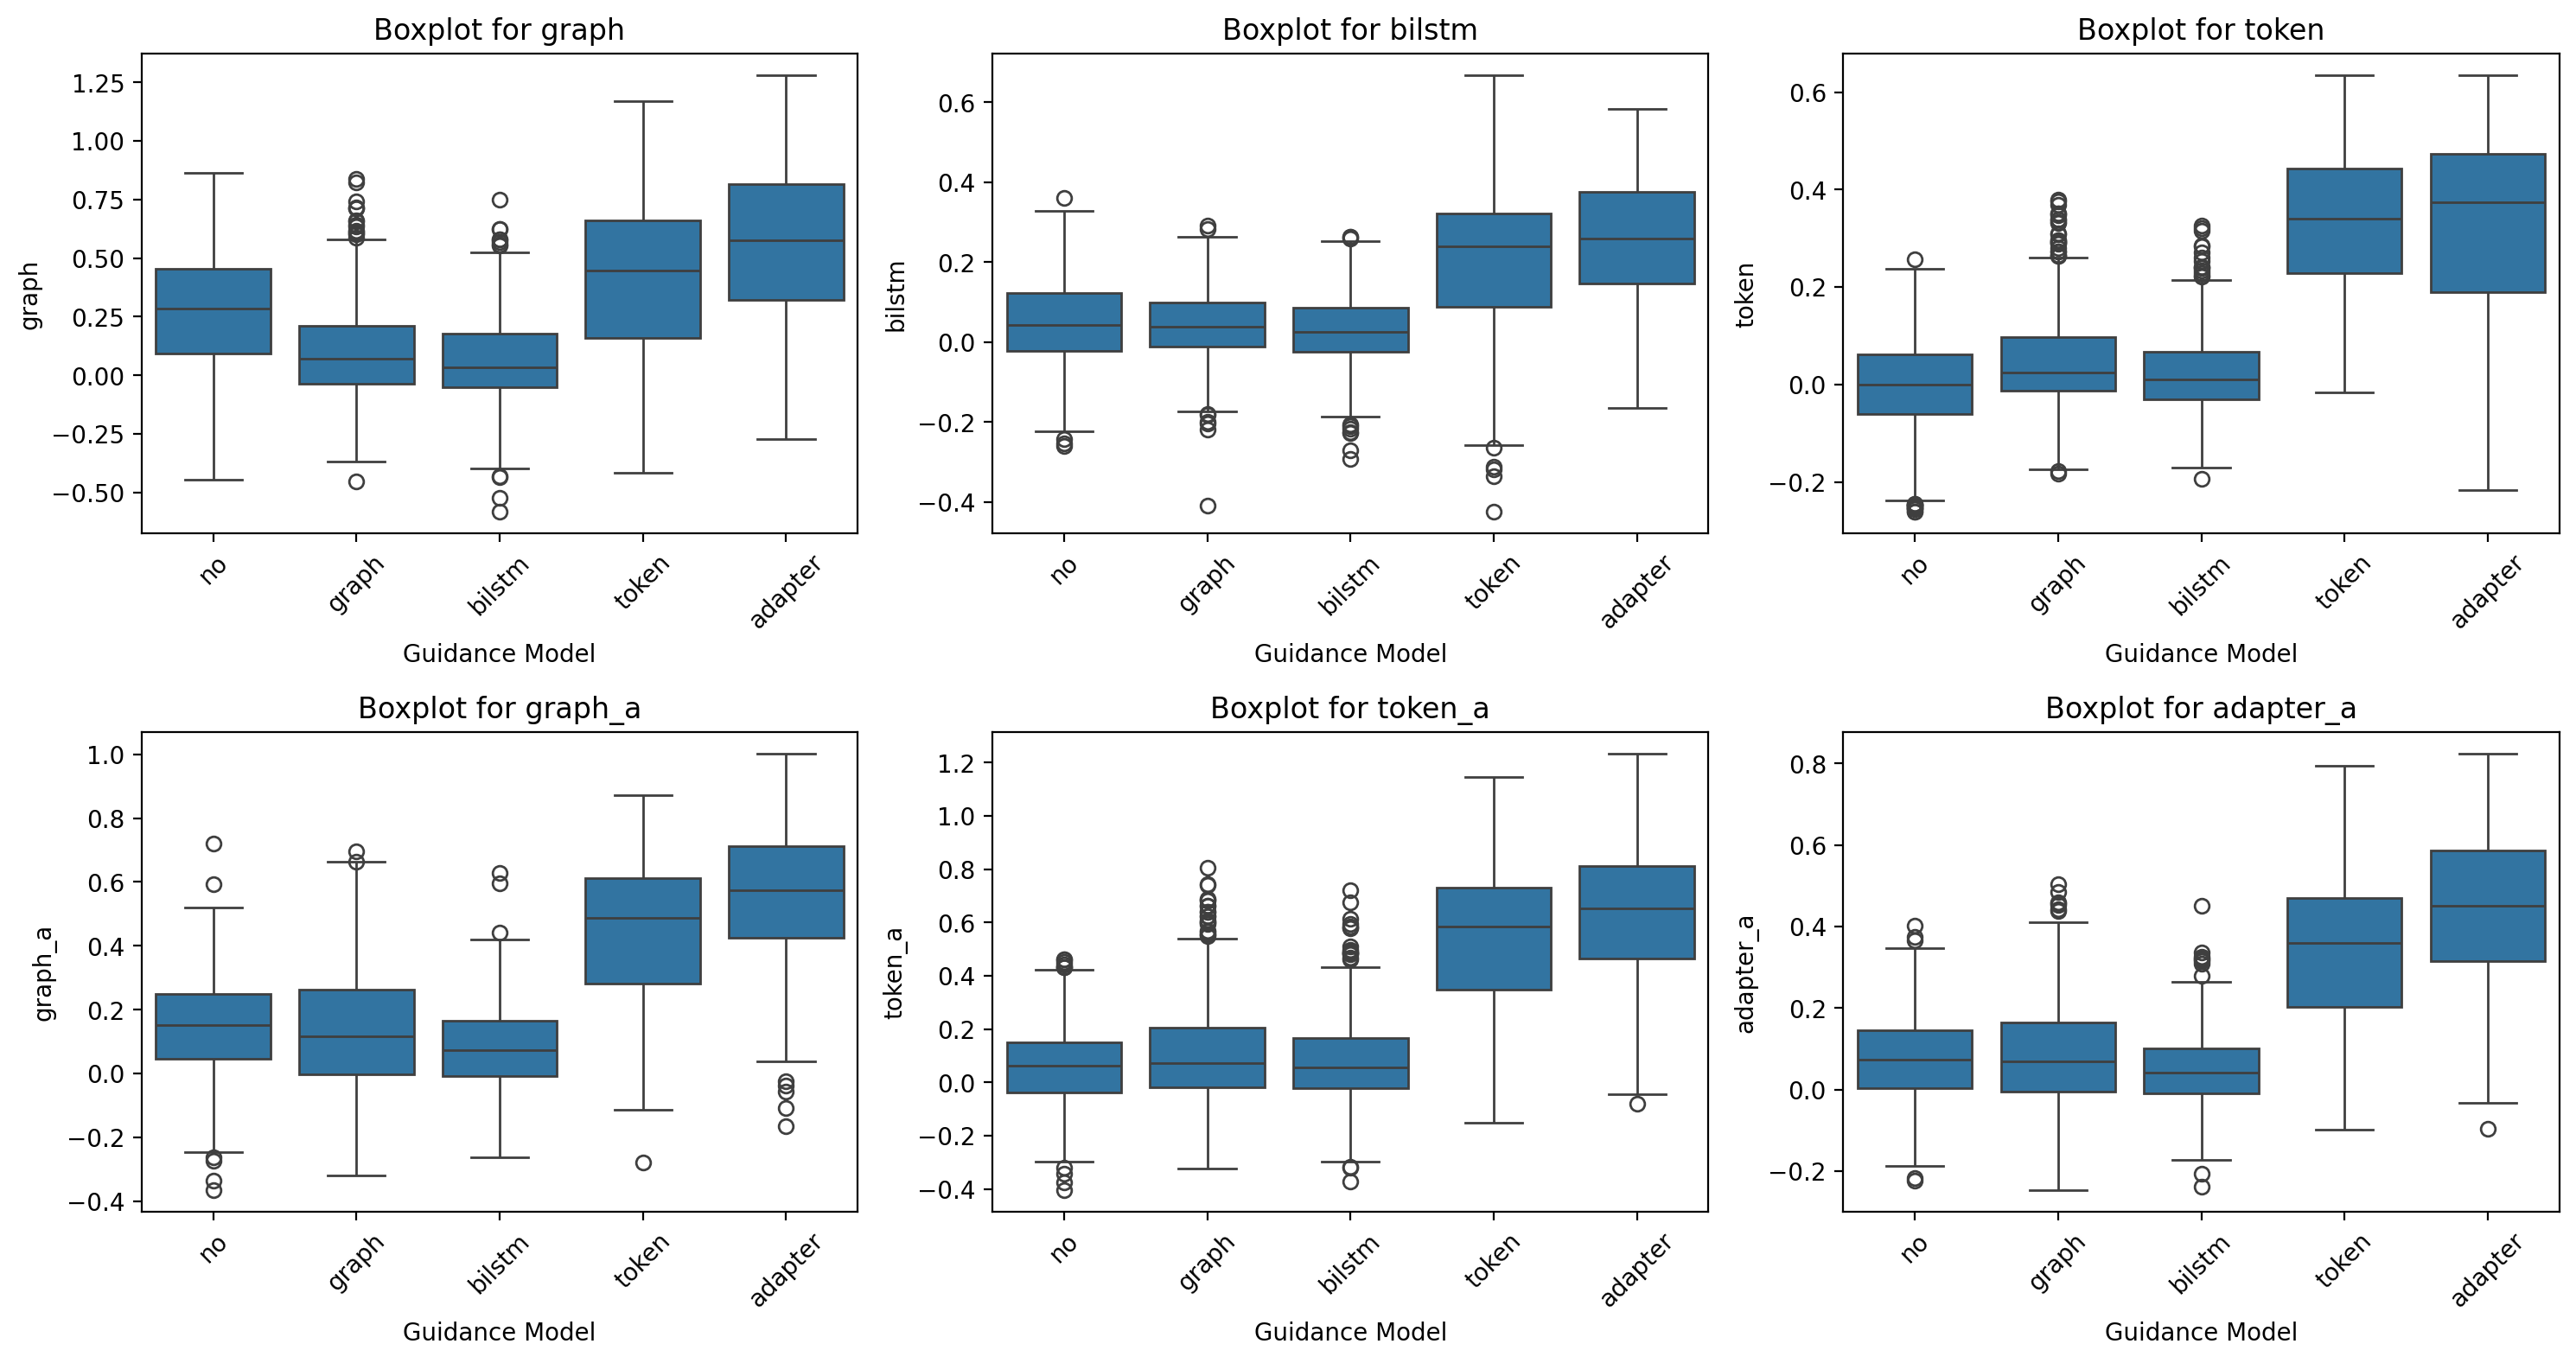

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Restrict the analysis to rows where contrastive training was enabled
# and select numeric metric columns automatically.
df_contra = df[df['contra'] == True].copy()

metrics = [
    col for col in df_contra.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_contra[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [10]:
from scipy import stats

# Use the same filtered subset for the statistical comparison.
df_filtered = df[df['contra'] == True].copy()
metrics = [
    col for col in df_filtered.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_filtered[col])
]
models_to_compare = ['token', 'adapter']

results = []
for metric in metrics:
    token_data = df_filtered[df_filtered['guidance_model'] == 'token'][metric]
    adapter_data = df_filtered[df_filtered['guidance_model'] == 'adapter'][metric]
    
    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data)
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

      metric  u_statistic       p_value  significant
0      graph     119918.0  4.602769e-13         True
1     bilstm     135598.5  1.198718e-05         True
2      token     149698.5  7.072433e-02        False
3    graph_a     115316.5  6.723307e-16         True
4    token_a     130036.5  6.974315e-08         True
5  adapter_a     107878.0  4.040440e-21         True


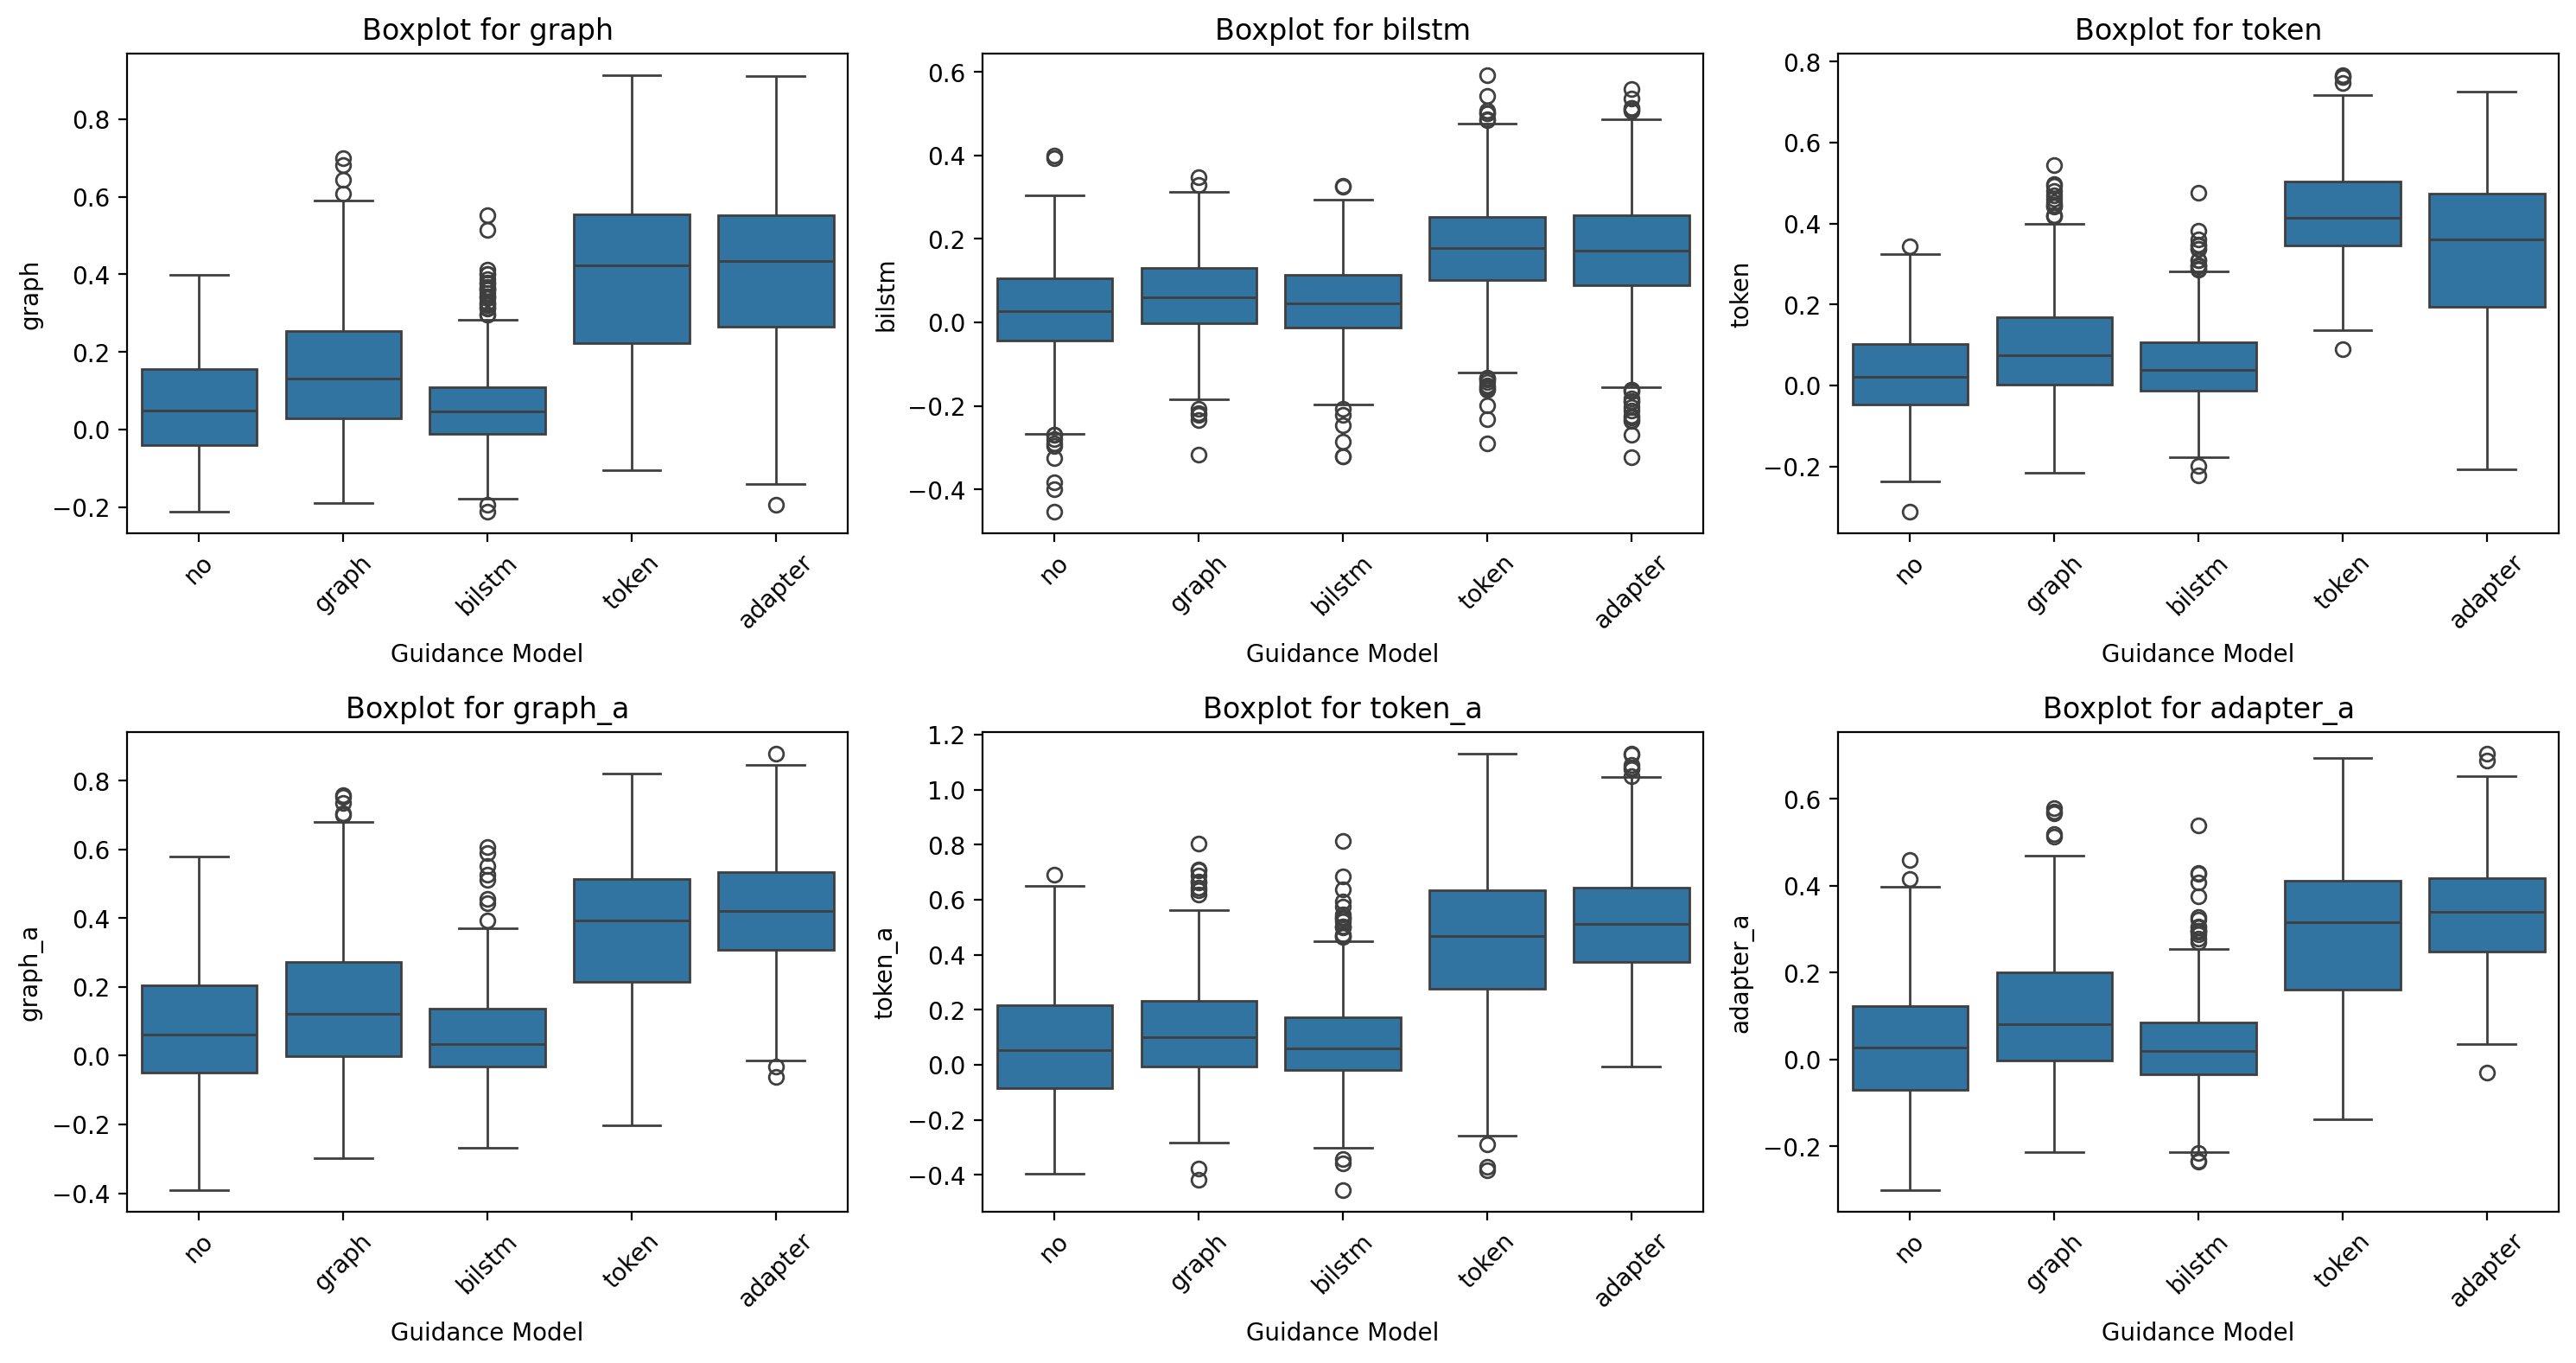

In [11]:
# Restrict the analysis to rows where contrastive training was NOT enabled
# and select numeric metric columns automatically.
df_no_contra = df[df['contra'] == False].copy()

metrics = [
    col for col in df_no_contra.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_contra[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_no_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [12]:
# Use the same filtered subset for the statistical comparison.
df_no_filtered = df[df['contra'] == False].copy()
metrics = [
    col for col in df_no_filtered.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_no_filtered[col])
]
models_to_compare = ['token', 'adapter']

results = []
for metric in metrics:
    token_data = df_no_filtered[df_no_filtered['guidance_model'] == 'token'][metric]
    adapter_data = df_no_filtered[df_no_filtered['guidance_model'] == 'adapter'][metric]
    
    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data)
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

      metric  u_statistic       p_value  significant
0      graph     155497.5  1.936612e-01        False
1     bilstm     169488.5  2.247722e-01        False
2      token     206402.5  4.269894e-15         True
3    graph_a     140809.0  8.179041e-05         True
4    token_a     142145.5  2.164961e-04         True
5  adapter_a     140666.5  7.348916e-05         True


/tmp/ipykernel_3691208/3619678584.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_adapter, x='contra_label', y=metric_col, order=['non-contra', 'contra'], palette='Set2')


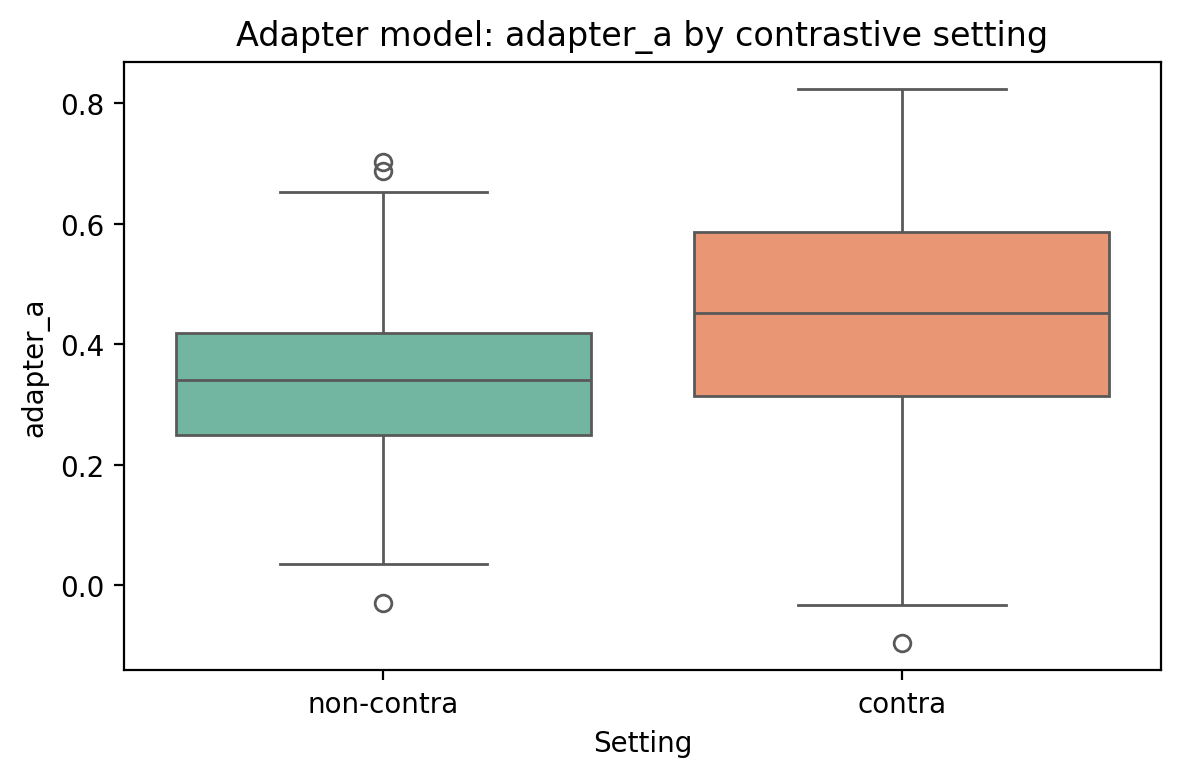

U statistic: 221254.000
p-value: 0.000000
Significant at 0.05: True


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Focus on the adapter model and pick the adapter metric column.
df_adapter = df[df['guidance_model'] == 'adapter'].copy()
metric_col = 'adapter_a' if 'adapter_a' in df_adapter.columns else next(
    (col for col in df_adapter.columns if col.startswith('adapter') and col.endswith('_a')),
    None,
)

if metric_col is None:
    raise ValueError(f"No adapter metric column found. Available columns: {df_adapter.columns.tolist()}")

# Make the contrastive labels easier to read.
df_adapter['contra_label'] = df_adapter['contra'].map({True: 'contra', False: 'non-contra'})

# Boxplot comparison.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_adapter, x='contra_label', y=metric_col, order=['non-contra', 'contra'], palette='Set2')
plt.title(f'Adapter model: {metric_col} by contrastive setting')
plt.xlabel('Setting')
plt.ylabel(metric_col)
plt.tight_layout()
plt.show()

# Statistical significance test.
contra_true = df_adapter.loc[df_adapter['contra'] == True, metric_col].dropna()
contra_false = df_adapter.loc[df_adapter['contra'] == False, metric_col].dropna()

u_stat, p_value = stats.mannwhitneyu(contra_true, contra_false, alternative='two-sided')
print(f'U statistic: {u_stat:.3f}')
print(f'p-value: {p_value:.6f}')
print(f'Significant at 0.05: {p_value < 0.05}')

In [14]:
common = [
    'b_E:7_@2;A:9_@2',
    'b_G:7_@2;D:9_@2'
]
uncommon = [
    'b_C#:hdim7_@2;D#:min_@2',
    'b_C:dim_@2;E:maj_@2'
]
new_t_known_c = [
    'b_A:min_@2;C#:maj_@2',
    'b_G:maj_@2;A#:11_@2'
]
new_t_new_c = [
    'b_E:maj13_@2;G#:sus2_@2',
    'b_D#:minmaj7_@2;B:maj6_@2'
]

In [ ]:
# seq_names = common
# seq_names = uncommon
# seq_names = new_t_known_c
# seq_names = new_t_new_c

In [26]:
# Restrict the analysis to rows where contrastive training was enabled
# and select numeric metric columns automatically.
# df_contra = df[df['contra'] == True].copy()
df_common = df_contra[df_contra['path'].str.contains(common[0], na=False) | df_contra['path'].str.contains(common[1], na=False)].copy()
df_uncommon = df_contra[df_contra['path'].str.contains(uncommon[0], na=False) | df_contra['path'].str.contains(uncommon[1], na=False)].copy()
df_ntkc = df_contra[df_contra['path'].str.contains(new_t_known_c[0], na=False) | df_contra['path'].str.contains(new_t_known_c[1], na=False)].copy()
df_ntnc = df_contra[df_contra['path'].str.contains(new_t_new_c[0], na=False) | df_contra['path'].str.contains(new_t_new_c[1], na=False)].copy()

print(df_contra.size)
print(df_common.size)
print(df_uncommon.size)
print(df_ntkc.size)
print(df_ntnc.size)
print(df_uncommon.head(10))

31482
7876
7832
7821
7150
                                                 path guidance_arch  contra  \
11  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
12  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
13  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
14  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
15  MIDIs/LoRA/contra/b_C#:hdim7_@2;D#:min_@2/step...          LoRA    True   
16  MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/...          LoRA    True   
17  MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/...          LoRA    True   
18  MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/...          LoRA    True   
19  MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/...          LoRA    True   
20  MIDIs/LoRA/contra/b_C:dim_@2;E:maj_@2/steps_8/...          LoRA    True   

    num_guidance_steps guidance_model     graph    bilstm     token   graph_a  \
11                   8 

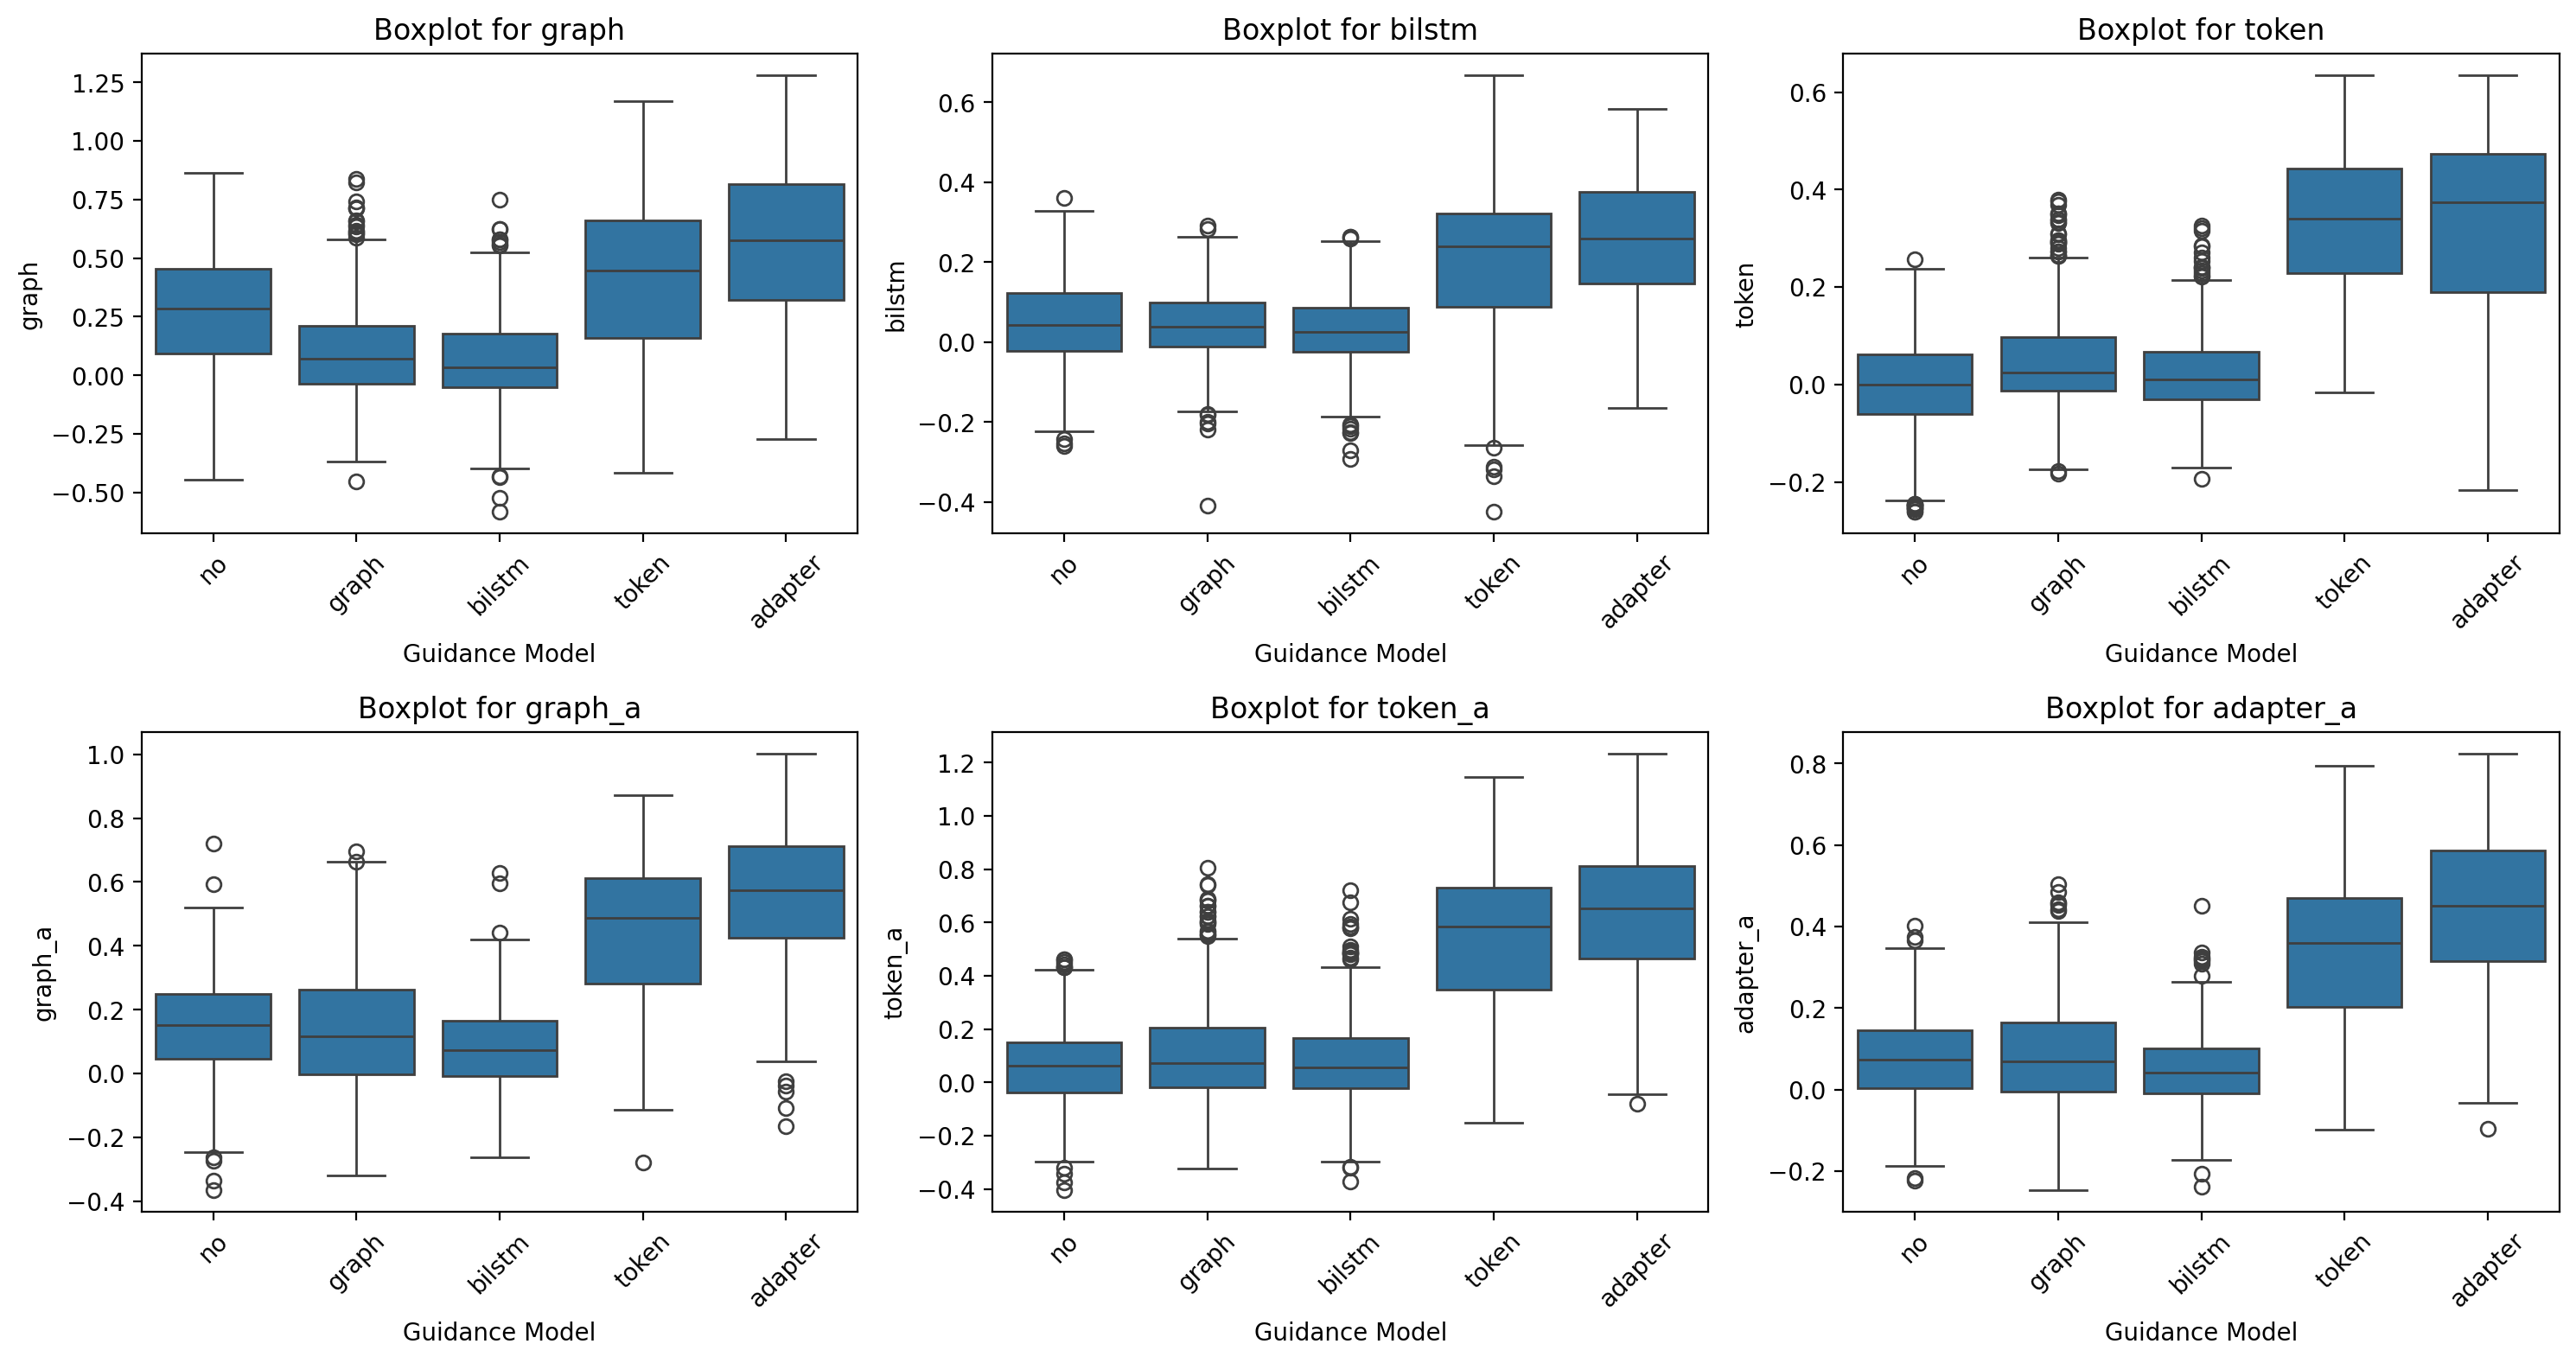

In [ ]:
# df_current = df_common
# df_current = df_uncommon
# df_current = df_ntkc
df_current = df_ntnc

metrics = [
    col for col in df_current.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_current[col])
]

# Create subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics[:len(axes)]):
    sns.boxplot(data=df_contra, x='guidance_model', y=metric, ax=axes[idx])
    axes[idx].set_title(f'Boxplot for {metric}')
    axes[idx].set_xlabel('Guidance Model')
    axes[idx].set_ylabel(metric)
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

for ax in axes[len(metrics):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy import stats

# df_common = df_contra[df_contra['path'].str.contains(seq_name, na=False)].copy()

metrics = [
    col for col in df_current.columns
    if col not in {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}
    and pd.api.types.is_numeric_dtype(df_current[col])
]

results = []
for metric in metrics:
    token_data = df_current.loc[df_current['guidance_model'] == 'token', metric].dropna()
    adapter_data = df_current.loc[df_current['guidance_model'] == 'adapter', metric].dropna()

    if len(token_data) == 0 or len(adapter_data) == 0:
        results.append({
            'metric': metric,
            'u_statistic': np.nan,
            'p_value': np.nan,
            'significant': False,
            'note': 'missing token or adapter rows'
        })
        continue

    u_stat, p_value = stats.mannwhitneyu(token_data, adapter_data, alternative='two-sided')
    results.append({
        'metric': metric,
        'u_statistic': u_stat,
        'p_value': p_value,
        'significant': p_value < 0.05 / len(metrics)
    })

results_df = pd.DataFrame(results)
print(results_df)

      metric  u_statistic       p_value  significant
0      graph       6963.5  1.984201e-05         True
1     bilstm       6906.5  1.359204e-05         True
2      token       5274.5  1.514615e-11         True
3    graph_a       5635.5  5.084837e-10         True
4    token_a       5941.5  8.060560e-09         True
5  adapter_a       4607.5  1.111540e-14         True


In [30]:
token_data

13      0.367215
18      0.403130
93      0.383127
98      0.445828
173     0.290877
          ...   
5618    0.401020
5693    0.327309
5698    0.502654
5773    0.610844
5778    0.542367
Name: adapter_a, Length: 141, dtype: float64

In [36]:
def boxplot_summary_table(df, group_col='guidance_model', exclude=None):
    if exclude is None:
        exclude = {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}

    metrics = [
        col for col in df.columns
        if col not in exclude and pd.api.types.is_numeric_dtype(df[col])
    ]

    agg_spec = {}
    for metric in metrics:
        agg_spec[f"{metric}_median"] = (metric, "median")
        # agg_spec[f"{metric}_q1"] = (metric, lambda s: s.quantile(0.25))
        # agg_spec[f"{metric}_q3"] = (metric, lambda s: s.quantile(0.75))
        # agg_spec[f"{metric}_iqr"] = (metric, lambda s: s.quantile(0.75) - s.quantile(0.25))
        # agg_spec[f"{metric}_n"] = (metric, "count")

    summary = df.groupby(group_col).agg(**agg_spec).reset_index()
    return summary

In [ ]:
# # for long table use this:
# def boxplot_summary_long(df, group_col='guidance_model', exclude=None):
#     if exclude is None:
#         exclude = {'path', 'guidance_arch', 'contra', 'num_guidance_steps', 'guidance_model'}

#     metrics = [
#         col for col in df.columns
#         if col not in exclude and pd.api.types.is_numeric_dtype(df[col])
#     ]

#     rows = []
#     for model, g in df.groupby(group_col):
#         for metric in metrics:
#             rows.append({
#                 group_col: model,
#                 'metric': metric,
#                 'median': g[metric].median(),
#                 'q1': g[metric].quantile(0.25),
#                 'q3': g[metric].quantile(0.75),
#                 'iqr': g[metric].quantile(0.75) - g[metric].quantile(0.25),
#                 'n': g[metric].count()
#             })

#     return pd.DataFrame(rows)

In [37]:
summary_contra = boxplot_summary_table(df_contra)
print(summary_contra.round(3).to_string(index=False))

guidance_model  graph_median  bilstm_median  token_median  graph_a_median  token_a_median  adapter_a_median
       adapter         0.576          0.260         0.374           0.574           0.654             0.451
        bilstm         0.033          0.025         0.011           0.072           0.057             0.041
         graph         0.069          0.040         0.025           0.118           0.074             0.069
            no         0.284          0.042        -0.000           0.152           0.062             0.074
         token         0.447          0.240         0.340           0.486           0.586             0.360


In [38]:
summary_common = boxplot_summary_table(df_common)
print(summary_common.round(3).to_string(index=False))

guidance_model  graph_median  bilstm_median  token_median  graph_a_median  token_a_median  adapter_a_median
       adapter         0.726          0.340         0.419           0.638           0.772             0.580
        bilstm         0.061          0.021         0.047           0.091           0.090             0.048
         graph         0.118          0.053         0.074           0.178           0.108             0.103
            no         0.394          0.032         0.018           0.181           0.018             0.091
         token         0.504          0.269         0.366           0.475           0.671             0.414


In [39]:
summary_uncommon = boxplot_summary_table(df_uncommon)
print(summary_uncommon.round(3).to_string(index=False))

guidance_model  graph_median  bilstm_median  token_median  graph_a_median  token_a_median  adapter_a_median
       adapter         0.675          0.280         0.397           0.687           0.749             0.535
        bilstm         0.042          0.027         0.006           0.081           0.022             0.024
         graph         0.053          0.024         0.021           0.097           0.056             0.046
            no         0.270          0.029        -0.108           0.133           0.018             0.012
         token         0.588          0.245         0.333           0.592           0.646             0.423


In [40]:
summary_ntkc = boxplot_summary_table(df_ntkc)
print(summary_ntkc.round(3).to_string(index=False))

guidance_model  graph_median  bilstm_median  token_median  graph_a_median  token_a_median  adapter_a_median
       adapter         0.652          0.321         0.447           0.567           0.697             0.439
        bilstm         0.011          0.033         0.009           0.088           0.078             0.059
         graph         0.027          0.056         0.024           0.085           0.068             0.055
            no         0.320          0.101         0.012           0.126           0.140             0.119
         token         0.607          0.338         0.463           0.560           0.699             0.406


In [ ]:
summary_ntnc = boxplot_summary_table(df_ntnc)
print(summary_ntnc.round(3).to_string(index=False))